# Social Media Computing Assignment
## Sentiment Analysis, Opinion Mining and Aspect-Based Sentiment Analysis using Machine Learning, Deep Learning and Transformer Models

In [2]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


# 1. Dataset Loading

In [3]:
import pandas as pd

# Define the path to your Flipkart dataset
# Usually it's in 'My Drive', so the path looks like this:
file_path = r"C:\Users\HP\Downloads\Social Media Computing Assignment\Dataset-SA.csv"

# Load the CSV file into a DataFrame (df)
df = pd.read_csv(file_path)

# Print a success message
print("Dataset loaded successfully!")

Dataset loaded successfully!


# 2. Exploratory Data Analysis (EDA)
## Dataset Overview and Data Inspection

In [4]:
# 1. Look at the first 5 rows to see column names and text content
print("--- First 5 Rows ---")
display(df.head())

# 2. Check the data types and look for missing (null) values
# If you have 10,000 rows but only 9,000 'Review_Text' entries, you'll need to fix that later.
print("\n--- Dataset Info ---")
df.info()

# 3. Check for missing values specifically
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 4. Check the distribution of ratings
# This tells you if your data is "imbalanced" (e.g., too many 5-star reviews)
print("\n--- Rating Distribution ---")
if 'Rating' in df.columns:
    print(df['Rating'].value_counts())
else:
    print("Column 'Rating' not found. Check your CSV column names!")

--- First 5 Rows ---


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB

--- Missing Values Count ---
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

--- Rating Distribution ---
Column 'Rating' not found. Check your CSV column names!


# 3. Data Cleaning and Preparation

In [5]:
# --- STEP 1: Fix the Rating error and check distribution ---
print("--- 'Rate' Distribution ---")
print(df['Rate'].value_counts())

# --- STEP 2: Check the mysterious 'Sentiment' column ---
print("\n--- 'Sentiment' Distribution ---")
print(df['Sentiment'].value_counts())

# --- STEP 3: Drop the missing values ---
# We are dropping any row that doesn't have text in the 'Review' column
print("\n--- Cleaning Data ---")
df_clean = df.dropna(subset=['Review', 'Summary']).copy()

# Let's see how many rows we have left
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")
print(f"We successfully removed {len(df) - len(df_clean)} useless rows.")

--- 'Rate' Distribution ---
Rate
5                                                                    118765
4                                                                     41894
1                                                                     21300
3                                                                     16599
2                                                                      6491
Pigeon Favourite Electric Kettle??????(1.5 L, Silver, Black)              1
Bajaj DX 2 L/W Dry Iron                                                   1
Nova Plus Amaze NI 10 1100 W Dry Iron?ÃÂ¿?ÃÂ¿(Grey & Turquoise)         1
Name: count, dtype: int64

--- 'Sentiment' Distribution ---
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

--- Cleaning Data ---
Original dataset size: 205052
Cleaned dataset size: 180379
We successfully removed 24673 useless rows.


# 4. NLP Text Preprocessing
## Lowercasing, Stopword Removal and Lemmatization

In [6]:
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# If running locally for the first time, you need to download these NLTK tools:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("\n--- STEP 4: Fixing 'Rate' Column ---")
# Force 'Rate' to be numeric, turn names/garbage into 'NaN', then drop them
df_clean['Rate'] = pd.to_numeric(df_clean['Rate'], errors='coerce')
df_clean = df_clean.dropna(subset=['Rate'])
print("Rate column is now strictly numeric.")





--- STEP 4: Fixing 'Rate' Column ---
Rate column is now strictly numeric.


In [7]:
print("\n--- STEP 5: Balancing the Dataset ---")
# Separate the sentiments
df_neg = df_clean[df_clean['Sentiment'] == 'negative']
df_neu = df_clean[df_clean['Sentiment'] == 'neutral']
# Take a random sample of positive reviews to match the number of negative ones
df_pos = df_clean[df_clean['Sentiment'] == 'positive'].sample(len(df_neg), random_state=42)

# Combine them back together
df_balanced = pd.concat([df_pos, df_neg, df_neu])
print(f"New Balanced Dataset Size: {len(df_balanced)}")
print(df_balanced['Sentiment'].value_counts())


--- STEP 5: Balancing the Dataset ---
New Balanced Dataset Size: 57607
Sentiment
positive    24400
negative    24400
neutral      8807
Name: count, dtype: int64


In [8]:
print("\n--- STEP 6: NLP Text Cleaning ---")
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Convert to lowercase
    text = str(text).lower()
    # 2. Remove special characters, punctuation, and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply the cleaning function to the Review column
print("Cleaning text... this might take a minute or two!")
df_balanced['Cleaned_Review'] = df_balanced['Review'].apply(clean_text)

print("\n--- Data Preparation 100% Complete! ---")
# Display the before and after
display(df_balanced[['Review', 'Cleaned_Review']].head())


--- STEP 6: NLP Text Cleaning ---
Cleaning text... this might take a minute or two!

--- Data Preparation 100% Complete! ---


,Review,Cleaned_Review
142200,very good,good
182972,brilliant,brilliant
144617,just okay,okay
25926,delightful,delightful
158743,worth every penny,worth every penny


# 5. Dataset Splitting

In [9]:
from sklearn.model_selection import train_test_split

X = df_balanced['Cleaned_Review']
y = df_balanced['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# 6. Feature Engineering
## TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 7. Traditional Machine Learning Models

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
X = df_balanced['Cleaned_Review']
y = df_balanced['Sentiment']

print("X and y created successfully!")
print("Number of reviews:", len(X))
print("Number of labels:", len(y))

print("\nSentiment distribution:")
print(y.value_counts())

X and y created successfully!
Number of reviews: 57607
Number of labels: 57607

Sentiment distribution:
Sentiment
positive    24400
negative    24400
neutral      8807
Name: count, dtype: int64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split completed!")
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Data split completed!
Training set size: 46085
Testing set size: 11522

Training sentiment distribution:
Sentiment
positive    19520
negative    19520
neutral      7045
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
negative    4880
positive    4880
neutral     1762
Name: count, dtype: int64


In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

print("\nExample TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF transformation completed!
Training TF-IDF shape: (46085, 1239)
Testing TF-IDF shape: (11522, 1239)

Example TF-IDF features:
['aboveaverage' 'aboveaverage product' 'absolute' 'absolute rubbish'
 'absolute rubbishnot' 'act' 'act lying' 'advisable' 'advisable buypoor'
 'ah' 'ah battery' 'ahead' 'ahead orderno' 'air' 'air purifier'
 'air quality' 'alam' 'allused' 'allused product' 'alternative']


In [16]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("Machine Learning models created:")
for name in models.keys():
    print("-", name)

Machine Learning models created:
- Naive Bayes
- Logistic Regression
- SVM
- Random Forest


## 7.1 Naive Bayes

Model: Naive Bayes
Accuracy: 0.7601978823120986
Precision: 0.7343106066161819
Recall: 0.7601978823120986
F1-Score: 0.7349429160327314

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.82      0.82      4880
     neutral       0.45      0.18      0.26      1762
    positive       0.74      0.91      0.82      4880

    accuracy                           0.76     11522
   macro avg       0.67      0.64      0.63     11522
weighted avg       0.73      0.76      0.73     11522



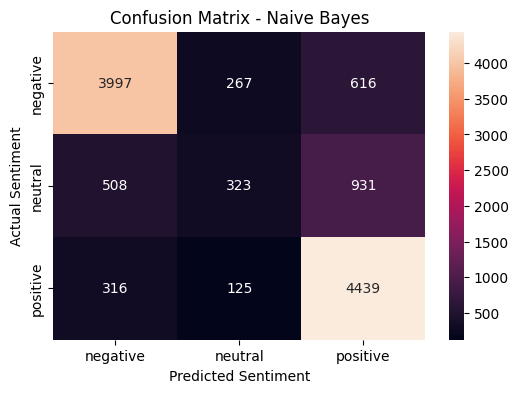

In [17]:
model_name = "Naive Bayes"
model = models[model_name]

model.fit(X_train_tfidf, y_train)
y_pred_nb = model.predict(X_test_tfidf)

print("Model:", model_name)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb, labels=model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

## 7.2 Logistic Regression

Model: Logistic Regression
Accuracy: 0.7690505120638778
Precision: 0.7430981285104907
Recall: 0.7690505120638778
F1-Score: 0.7499661080344175

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.87      0.82      4880
     neutral       0.44      0.23      0.30      1762
    positive       0.81      0.87      0.84      4880

    accuracy                           0.77     11522
   macro avg       0.68      0.65      0.65     11522
weighted avg       0.74      0.77      0.75     11522



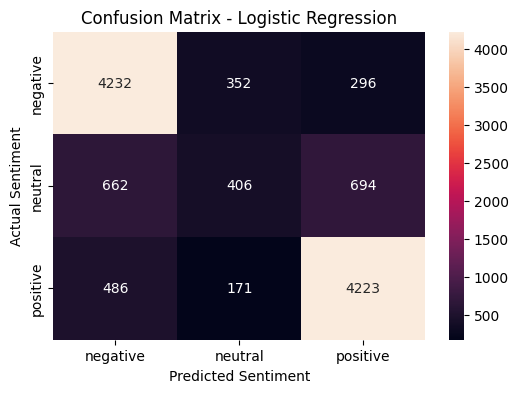

In [18]:
model_name = "Logistic Regression"
model = models[model_name]

model.fit(X_train_tfidf, y_train)
y_pred_lr = model.predict(X_test_tfidf)

print("Model:", model_name)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr, labels=model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

## 7.3 Support Vector Machine (SVM)

Model: SVM
Accuracy: 0.7687901406005901
Precision: 0.742879865281183
Recall: 0.7687901406005901
F1-Score: 0.7498304681471433

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.87      0.82      4880
     neutral       0.44      0.23      0.30      1762
    positive       0.81      0.87      0.84      4880

    accuracy                           0.77     11522
   macro avg       0.68      0.65      0.65     11522
weighted avg       0.74      0.77      0.75     11522



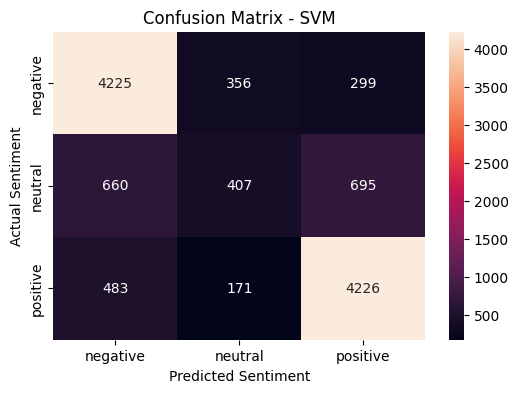

In [19]:
model_name = "SVM"
model = models[model_name]

model.fit(X_train_tfidf, y_train)
y_pred_svm = model.predict(X_test_tfidf)

print("Model:", model_name)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred_svm, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm, labels=model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

## 7.4 Random Forest

Model: Random Forest
Accuracy: 0.7681826071862524
Precision: 0.7422084736767819
Recall: 0.7681826071862524
F1-Score: 0.7491354042650505

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.86      0.82      4880
     neutral       0.44      0.23      0.30      1762
    positive       0.81      0.87      0.84      4880

    accuracy                           0.77     11522
   macro avg       0.68      0.65      0.65     11522
weighted avg       0.74      0.77      0.75     11522



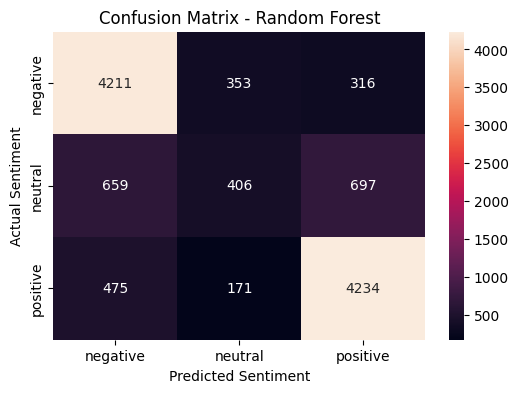

In [20]:
model_name = "Random Forest"
model = models[model_name]

model.fit(X_train_tfidf, y_train)
y_pred_rf = model.predict(X_test_tfidf)

print("Model:", model_name)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred_rf, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

## 7.5 Machine Learning Model Comparison

In [21]:
results = [
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, y_pred_nb),
        "Precision": precision_score(y_test, y_pred_nb, average='weighted'),
        "Recall": recall_score(y_test, y_pred_nb, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_nb, average='weighted')
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr, average='weighted'),
        "Recall": recall_score(y_test, y_pred_lr, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_lr, average='weighted')
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average='weighted'),
        "Recall": recall_score(y_test, y_pred_svm, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_svm, average='weighted')
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average='weighted'),
        "Recall": recall_score(y_test, y_pred_rf, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_rf, average='weighted')
    }
]

results_df = pd.DataFrame(results)

print("Model Comparison Results:")
display(results_df)

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135


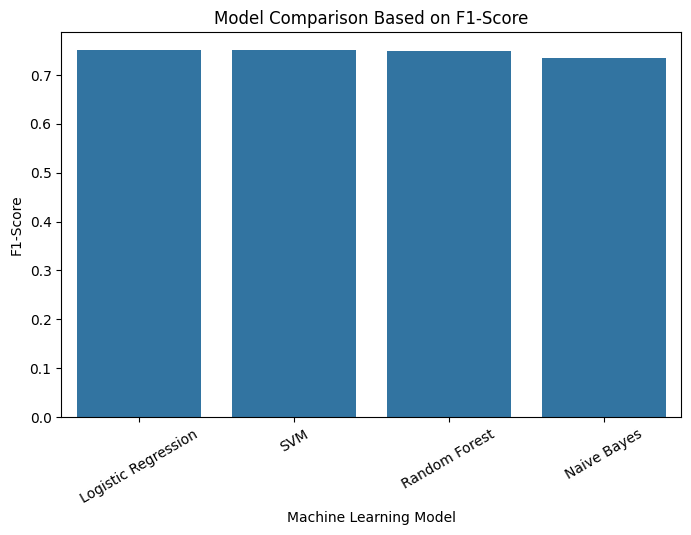

Best model based on F1-score:


,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966


In [22]:
results_df_sorted = results_df.sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df_sorted,
    x="Model",
    y="F1-Score"
)
plt.title("Model Comparison Based on F1-Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=30)
plt.show()

print("Best model based on F1-score:")
display(results_df_sorted.head(1))

## 7.6 Cross Validation

In [23]:
X_tfidf_all = tfidf.fit_transform(X)

print("--- 5-Fold Cross Validation Results ---")

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_tfidf_all,
        y,
        cv=5,
        scoring='f1_weighted'
    )
    
    print(f"{model_name}:")
    print("Scores:", scores)
    print(f"Mean F1-score: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print()

--- 5-Fold Cross Validation Results ---
Naive Bayes:
Scores: [0.73536437 0.74072777 0.72548855 0.71999099 0.68967075]
Mean F1-score: 0.7222
Standard Deviation: 0.0178

Logistic Regression:
Scores: [0.7442865  0.75439767 0.73711186 0.73475073 0.70572389]
Mean F1-score: 0.7353
Standard Deviation: 0.0163

SVM:
Scores: [0.74413876 0.75366569 0.73707127 0.7346359  0.70012305]
Mean F1-score: 0.7339
Standard Deviation: 0.0181

Random Forest:
Scores: [0.74322108 0.75277386 0.73567065 0.73436877 0.70019161]
Mean F1-score: 0.7332
Standard Deviation: 0.0178



# 8. Data Visualization

In [24]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

## 8.1 Sentiment Distribution

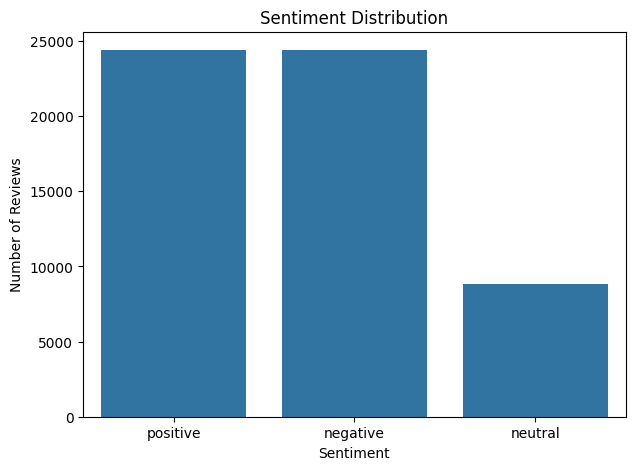

In [25]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_balanced,
    x='Sentiment',
    order=df_balanced['Sentiment'].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## 8.2 Rating Distribution

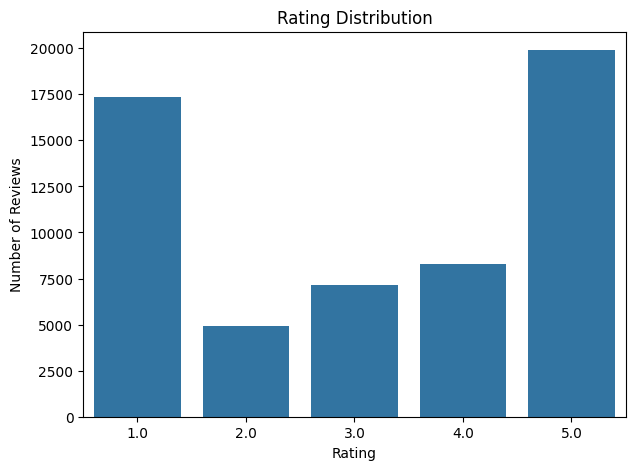

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_balanced,
    x='Rate',
    order=sorted(df_balanced['Rate'].dropna().unique())
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

## 8.3 Word Cloud Analysis

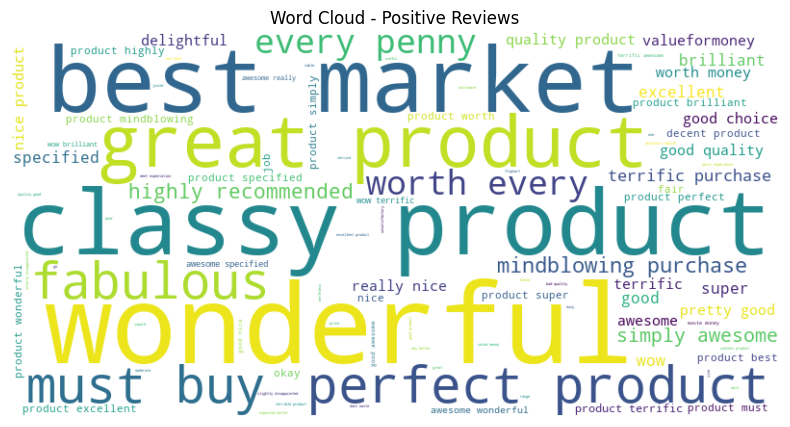

In [27]:
positive_text = " ".join(
    df_balanced[df_balanced['Sentiment'] == 'positive']['Cleaned_Review']
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Positive Reviews")
plt.show()

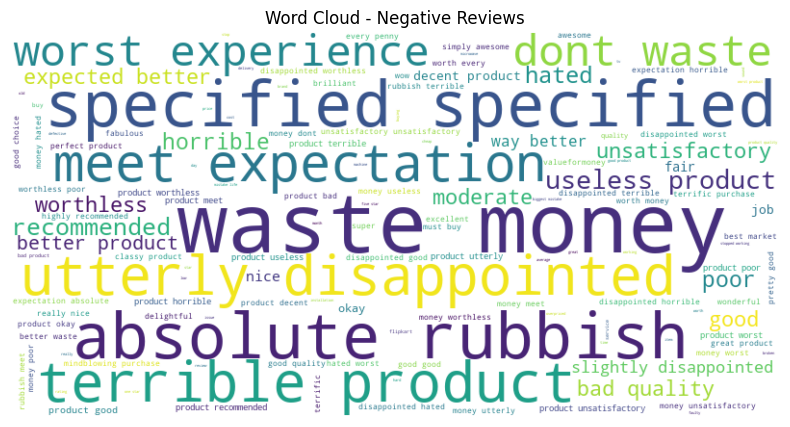

In [28]:
negative_text = " ".join(
    df_balanced[df_balanced['Sentiment'] == 'negative']['Cleaned_Review']
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Negative Reviews")
plt.show()

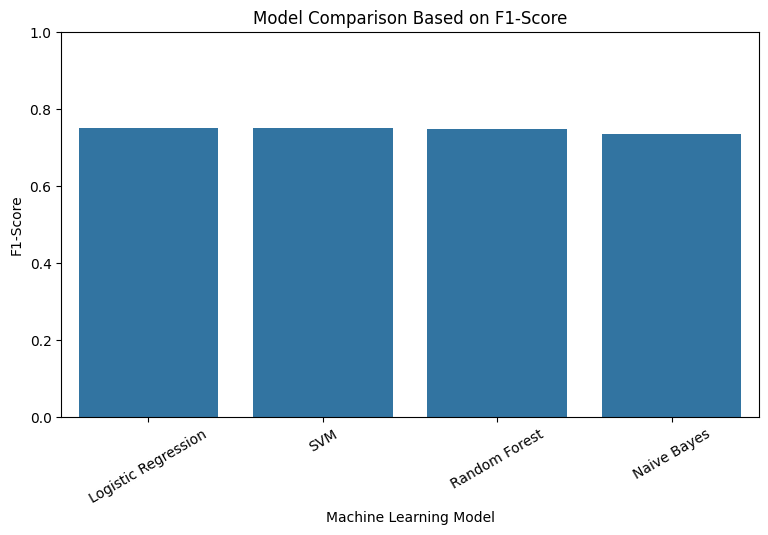

Best model:


,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966


In [29]:
results_df_sorted = results_df.sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=results_df_sorted,
    x="Model",
    y="F1-Score"
)

plt.title("Model Comparison Based on F1-Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

print("Best model:")
display(results_df_sorted.head(1))

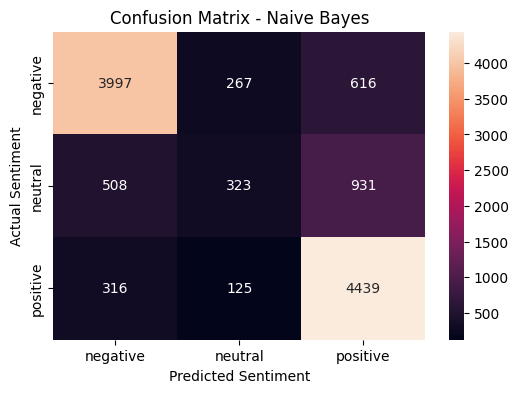

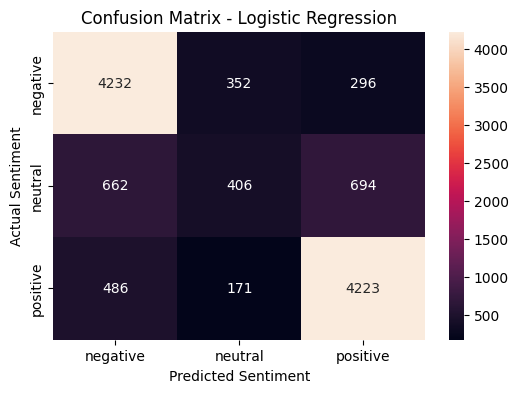

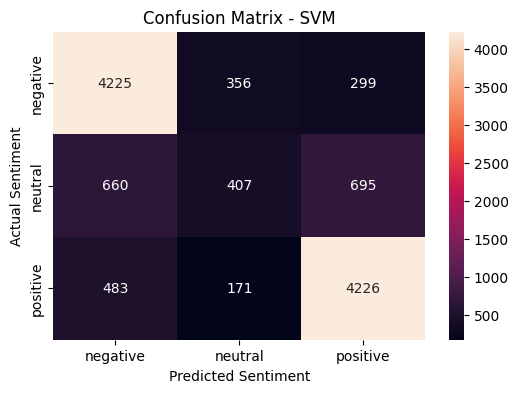

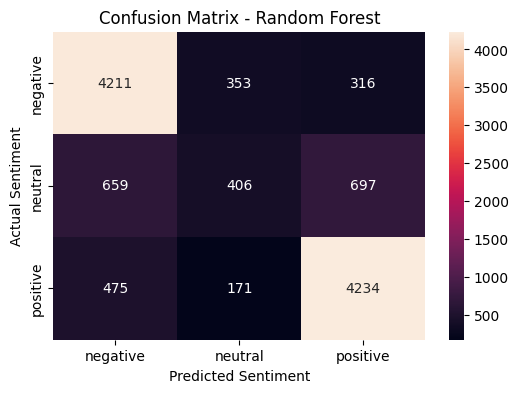

In [30]:
predictions = {
    "Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=sorted(y_test.unique()),
        yticklabels=sorted(y_test.unique())
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Sentiment")
    plt.show()

# 9. Aspect-Based Sentiment Analysis (ABSA)

In [31]:
aspect_keywords = {
    "Price / Value": [
        "price", "cost", "cheap", "expensive", "money", "value", 
        "worth", "budget", "affordable", "overpriced"
    ],

    "Product Quality": [
        "quality", "durable", "poor", "excellent", "good", "bad", 
        "solid", "strong", "weak", "damage", "defective"
    ],

    "Delivery / Shipping": [
        "delivery", "delivered", "shipping", "late", "delay", 
        "fast delivery", "on time", "received"
    ],

    "Packaging": [
        "packaging", "package", "packed", "box", "parcel", 
        "broken", "damaged"
    ],

    "Size / Fit": [
        "size", "fit", "tight", "loose", "small", "large", 
        "men", "women", "inch"
    ],

    "Color / Design": [
        "color", "colour", "black", "white", "blue", "grey", 
        "brown", "multicolor", "design", "look", "looks", "style"
    ],

    "Performance / Working": [
        "performance", "working", "works", "slow", "fast", 
        "smooth", "power", "speed"
    ],

    "Cooling / Air Flow": [
        "cooler", "cooling", "air", "airflow", "fan", 
        "room", "water"
    ],

    "Sound / Audio": [
        "sound", "audio", "bass", "speaker", "bluetooth", 
        "volume", "noise"
    ],

    "Battery / Charging": [
        "battery", "charge", "charging", "backup", "powerbank"
    ],

    "Screen / Display": [
        "screen", "display", "led", "inch", "resolution"
    ],

    "Customer Service / Return": [
        "service", "support", "return", "refund", "replacement", 
        "flipkart", "seller"
    ]
}

print("Product aspects created successfully!")

for aspect, keywords in aspect_keywords.items():
    print(aspect, ":", keywords)

Product aspects created successfully!
Price / Value : ['price', 'cost', 'cheap', 'expensive', 'money', 'value', 'worth', 'budget', 'affordable', 'overpriced']
Product Quality : ['quality', 'durable', 'poor', 'excellent', 'good', 'bad', 'solid', 'strong', 'weak', 'damage', 'defective']
Delivery / Shipping : ['delivery', 'delivered', 'shipping', 'late', 'delay', 'fast delivery', 'on time', 'received']
Packaging : ['packaging', 'package', 'packed', 'box', 'parcel', 'broken', 'damaged']
Size / Fit : ['size', 'fit', 'tight', 'loose', 'small', 'large', 'men', 'women', 'inch']
Color / Design : ['color', 'colour', 'black', 'white', 'blue', 'grey', 'brown', 'multicolor', 'design', 'look', 'looks', 'style']
Performance / Working : ['performance', 'working', 'works', 'slow', 'fast', 'smooth', 'power', 'speed']
Cooling / Air Flow : ['cooler', 'cooling', 'air', 'airflow', 'fan', 'room', 'water']
Sound / Audio : ['sound', 'audio', 'bass', 'speaker', 'bluetooth', 'volume', 'noise']
Battery / Charging

## 9.1 Aspect Extraction

In [32]:
def detect_aspects(text):
    detected = []
    text = str(text).lower()
    
    for aspect, keywords in aspect_keywords.items():
        for keyword in keywords:
            if keyword in text:
                detected.append(aspect)
                break
    
    return detected

df_balanced['Detected_Aspects'] = df_balanced['Cleaned_Review'].apply(detect_aspects)

print("Aspect detection completed!")
display(df_balanced[['Review', 'Cleaned_Review', 'Sentiment', 'Detected_Aspects']].head(10))

Aspect detection completed!


,Review,Cleaned_Review,Sentiment,Detected_Aspects
142200,very good,good,positive,[Product Quality]
182972,brilliant,brilliant,positive,[]
144617,just okay,okay,positive,[]
25926,delightful,delightful,positive,[]
158743,worth every penny,worth every penny,positive,[Price / Value]
205031,must buy!,must buy,positive,[]
148403,worst experience ever!,worst experience ever,positive,[]
24938,best in the market!,best market,positive,[]
110817,super!,super,positive,[]
152316,just wow!,wow,positive,[]


In [33]:
df_aspects = df_balanced.explode('Detected_Aspects')

df_aspects = df_aspects.dropna(subset=['Detected_Aspects'])

df_aspects = df_aspects.reset_index(drop=True)####

print("Aspect dataset created!")
print("Number of aspect mentions:", len(df_aspects))

display(df_aspects[['Cleaned_Review', 'Sentiment', 'Detected_Aspects']].head())

Aspect dataset created!
Number of aspect mentions: 17700


,Cleaned_Review,Sentiment,Detected_Aspects
0,good,positive,Product Quality
1,worth every penny,positive,Price / Value
2,highly recommended,positive,Size / Fit
3,waste money,positive,Price / Value
4,highly recommended,positive,Size / Fit


## 9.2 Aspect Analysis Visualization

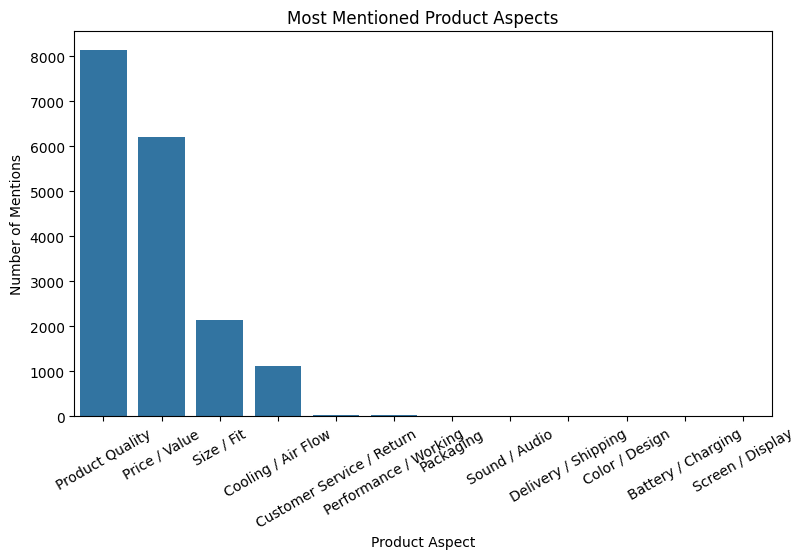

In [34]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_aspects,
    x='Detected_Aspects',
    order=df_aspects['Detected_Aspects'].value_counts().index
)

plt.title("Most Mentioned Product Aspects")
plt.xlabel("Product Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30)
plt.show()

In [35]:
print(df_aspects.index.is_unique)

True


In [36]:
aspect_sentiment_table = pd.crosstab(
    df_aspects['Detected_Aspects'],
    df_aspects['Sentiment']
)

print("Aspect-Based Sentiment Table:")
display(aspect_sentiment_table)

Aspect-Based Sentiment Table:


Sentiment,negative,neutral,positive
Detected_Aspects,,,
Battery / Charging,3,1,0
Color / Design,5,0,3
Cooling / Air Flow,450,446,214
Customer Service / Return,23,3,7
Delivery / Shipping,9,0,1
Packaging,9,0,3
Performance / Working,15,2,4
Price / Value,3549,678,1984
Product Quality,3175,1594,3373


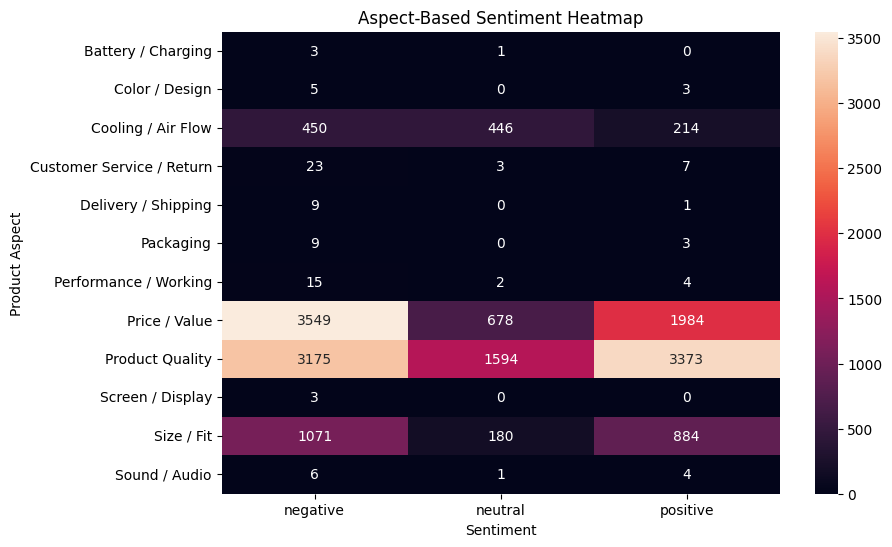

In [37]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    aspect_sentiment_table,
    annot=True,
    fmt='d'
)

plt.title("Aspect-Based Sentiment Heatmap")
plt.xlabel("Sentiment")
plt.ylabel("Product Aspect")
plt.show()

In [38]:
aspect_sentiment_percentage = aspect_sentiment_table.div(
    aspect_sentiment_table.sum(axis=1),
    axis=0
) * 100

print("Aspect-Based Sentiment Percentage:")
display(aspect_sentiment_percentage.round(2))

Aspect-Based Sentiment Percentage:


Sentiment,negative,neutral,positive
Detected_Aspects,,,
Battery / Charging,75.00,25.00,0.00
Color / Design,62.50,0.00,37.50
Cooling / Air Flow,40.54,40.18,19.28
Customer Service / Return,69.70,9.09,21.21
Delivery / Shipping,90.00,0.00,10.00
Packaging,75.00,0.00,25.00
Performance / Working,71.43,9.52,19.05
Price / Value,57.14,10.92,31.94
Product Quality,39.00,19.58,41.43


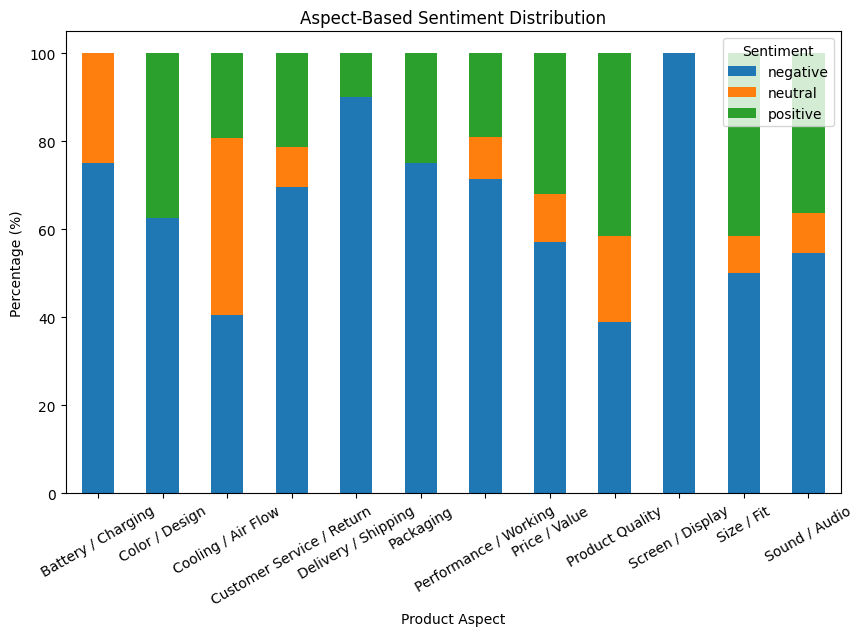

In [39]:
aspect_sentiment_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Aspect-Based Sentiment Distribution")
plt.xlabel("Product Aspect")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="Sentiment")
plt.show()

# 10. Opinion Mining
## 10.1 VADER Sentiment Analysis

In [40]:
!pip install vaderSentiment

In [41]:
#import
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [42]:
#Extract Opinion Scores
def get_opinion_score(text):
    score = analyzer.polarity_scores(str(text))
    return score['compound']

df_balanced['Opinion_Score'] = df_balanced['Review'].apply(
    get_opinion_score
)

df_balanced[['Review', 'Opinion_Score']].head()

,Review,Opinion_Score
142200,very good,0.4927
182972,brilliant,0.5859
144617,just okay,0.2263
25926,delightful,0.5859
158743,worth every penny,0.2263


In [43]:
#create opinion label
def opinion_label(score):
    if score >= 0.05:
        return 'Positive Opinion'
    elif score <= -0.05:
        return 'Negative Opinion'
    else:
        return 'Neutral Opinion'

df_balanced['Opinion_Label'] = df_balanced[
    'Opinion_Score'
].apply(opinion_label)

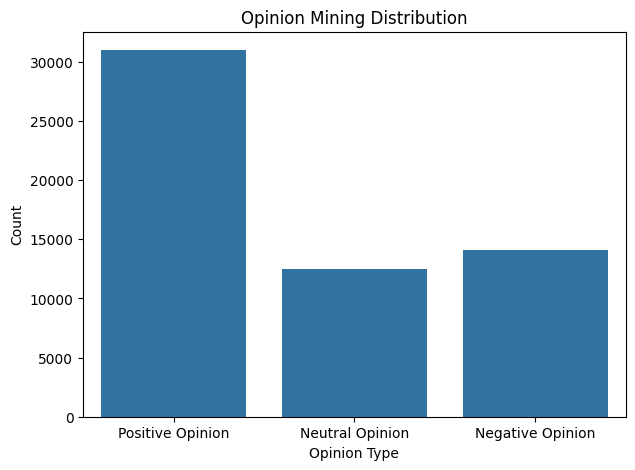

In [44]:
#Opinion distribution chart
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_balanced,
    x='Opinion_Label',
    order=[
        'Positive Opinion',
        'Neutral Opinion',
        'Negative Opinion'
    ]
)

plt.title("Opinion Mining Distribution")
plt.xlabel("Opinion Type")
plt.ylabel("Count")
plt.show()

## 10.2 Opinion Word Analysis

In [45]:
#Most common positive opinion work
from collections import Counter

positive_reviews = " ".join(
    df_balanced[
        df_balanced['Opinion_Label']
        == 'Positive Opinion'
    ]['Cleaned_Review']
)

positive_words = positive_reviews.split()

top_positive = Counter(
    positive_words
).most_common(20)

top_positive_df = pd.DataFrame(
    top_positive,
    columns=['Word', 'Frequency']
)

display(top_positive_df)

,Word,Frequency
0,product,5570
1,good,4263
2,nice,2686
3,awesome,2122
4,terrific,2076
5,money,1871
6,wonderful,1842
7,worth,1771
8,better,1482
9,okay,1195


In [46]:
#Most common negative opinion work
negative_reviews = " ".join(
    df_balanced[
        df_balanced['Opinion_Label']
        == 'Negative Opinion'
    ]['Cleaned_Review']
)

negative_words = negative_reviews.split()

top_negative = Counter(
    negative_words
).most_common(20)

top_negative_df = pd.DataFrame(
    top_negative,
    columns=['Word', 'Frequency']
)

display(top_negative_df)

,Word,Frequency
0,product,2374
1,disappointed,1986
2,terrible,1226
3,utterly,1223
4,waste,1204
5,money,1203
6,worthless,1201
7,worst,1180
8,experience,1159
9,ever,1159


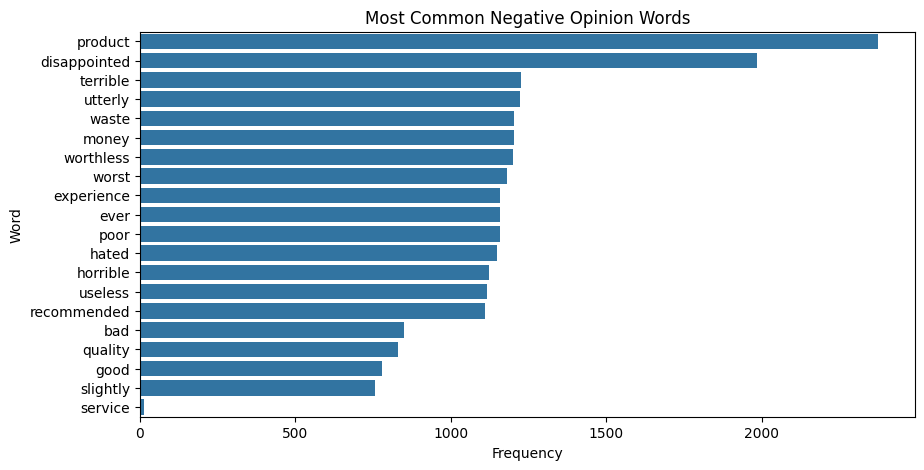

In [47]:
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_negative_df,
    x='Frequency',
    y='Word'
)

plt.title(
    "Most Common Negative Opinion Words"
)

plt.show()

## 10.3 Opinion Target Extraction using spaCy

In [48]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 11.9 MB/s eta 0:00:01
     --------- ------------------------------ 2.9/12.8 MB 11.3 MB/s eta 0:00:01
     --------- ------------------------------ 2.9/12.8 MB 11.3 MB/s eta 0:00:01
     --------- ------------------------------ 3.1/12.8 MB 4.7 MB/s eta 0:00:03
     ---------- ----------------------------- 3.4/12.8 MB 3.8 MB/s eta 0:00:03
     ------------- -------------------------- 4.5/12.8 MB 3.8 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 4.5 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 5.1 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 5.7 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 6.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now lo

In [49]:
#Import
import spacy

nlp = spacy.load("en_core_web_sm")

In [50]:
#Extract opinion target
sample_reviews = df_balanced['Review'].head(1000)

In [51]:
opinion_pairs = []

for review in sample_reviews:
    
    doc = nlp(str(review))
    
    for token in doc:
        
        # adjective describing noun
        if token.pos_ == "ADJ":
            
            head = token.head
            
            if head.pos_ in ["NOUN", "PROPN"]:
                
                opinion_pairs.append({
                    "Target": head.text,
                    "Opinion": token.text
                })

opinion_df = pd.DataFrame(opinion_pairs)

print(opinion_df.head(20))

      Target   Opinion
0    product    classy
1    product      nice
2    product    classy
3   purchase  terrific
4    product    decent
5    product   perfect
6     choice      good
7     choice      good
8    product   perfect
9   purchase  terrific
10   product     great
11    choice      good
12   product     great
13   product    classy
14   product    decent
15   product    classy
16    choice      good
17   product     great
18  purchase  terrific
19  purchase  terrific


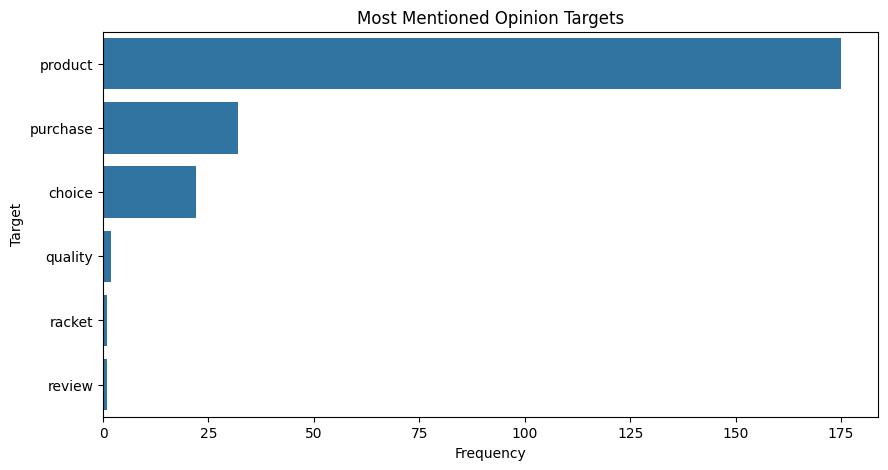

In [52]:
#Top Opninion target
top_targets = opinion_df['Target'].value_counts().head(15)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_targets.values,
    y=top_targets.index
)

plt.title("Most Mentioned Opinion Targets")
plt.xlabel("Frequency")
plt.ylabel("Target")

plt.show()

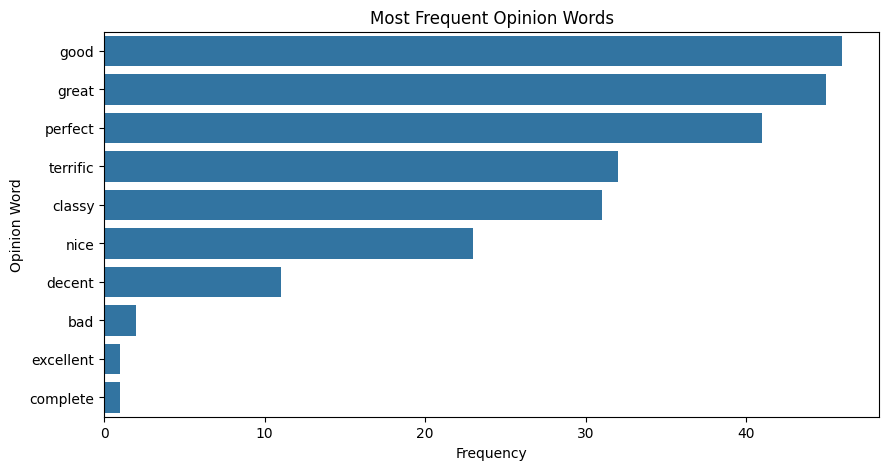

In [53]:
#Top Opinion word
top_opinions = opinion_df['Opinion'].value_counts().head(15)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_opinions.values,
    y=top_opinions.index
)

plt.title("Most Frequent Opinion Words")
plt.xlabel("Frequency")
plt.ylabel("Opinion Word")

plt.show()

# 11. Deep Learning Models

## 11.1 BiLSTM Model

In [54]:
#Create Create Encodings
from transformers import AutoTokenizer

MAX_LEN = 64

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

print("Tokenization completed!")

Tokenization completed!


In [55]:
#Create Dataset Class
import torch
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [56]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [57]:
#Create Dataset Objects
train_dataset = ReviewDataset(
    train_encodings,
    y_train
)

test_dataset = ReviewDataset(
    test_encodings,
    y_test
)

print("Datasets created!")

Datasets created!


In [58]:
#Create DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

print("DataLoaders ready!")

DataLoaders ready!


In [59]:
#BiLSTM Model
import torch.nn as nn

class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        output_dim=3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, input_ids):

        embedded = self.embedding(input_ids)

        _, (hidden, _) = self.lstm(
            embedded
        )

        hidden = torch.cat(
            (
                hidden[-2],
                hidden[-1]
            ),
            dim=1
        )

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output

In [60]:
#Initialize Model
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model_bilstm = BiLSTMClassifier(
    vocab_size=tokenizer.vocab_size,
    output_dim=3
)

model_bilstm = model_bilstm.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_bilstm.parameters(),
    lr=0.001
)

print(device)
print("BiLSTM initialized!")

cpu
BiLSTM initialized!


In [61]:
#Training Loop
EPOCHS = 3

for epoch in range(EPOCHS):

    model_bilstm.train()

    running_loss = 0

    for batch in train_loader:

        input_ids = batch[
            'input_ids'
        ].to(device)

        labels = batch[
            'labels'
        ].to(device)

        optimizer.zero_grad()

        outputs = model_bilstm(
            input_ids
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Loss: {running_loss:.4f}"
    )

print("Training completed!")

Epoch 1/3, Loss: 881.7787
Epoch 2/3, Loss: 854.4237
Epoch 3/3, Loss: 849.0677
Training completed!


In [62]:
print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [63]:
#Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

model_bilstm.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            'input_ids'
        ].to(device)

        labels = batch[
            'labels'
        ].to(device)

        outputs = model_bilstm(
            input_ids
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

bilstm_accuracy = accuracy_score(
    true_labels,
    predictions
)

bilstm_precision = precision_score(
    true_labels,
    predictions,
    average='weighted'
)

bilstm_recall = recall_score(
    true_labels,
    predictions,
    average='weighted'
)

bilstm_f1 = f1_score(
    true_labels,
    predictions,
    average='weighted'
)

print(
    classification_report(
        true_labels,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      4880
           1       0.45      0.12      0.19      1762
           2       0.77      0.91      0.83      4880

    accuracy                           0.77     11522
   macro avg       0.67      0.63      0.62     11522
weighted avg       0.73      0.77      0.73     11522



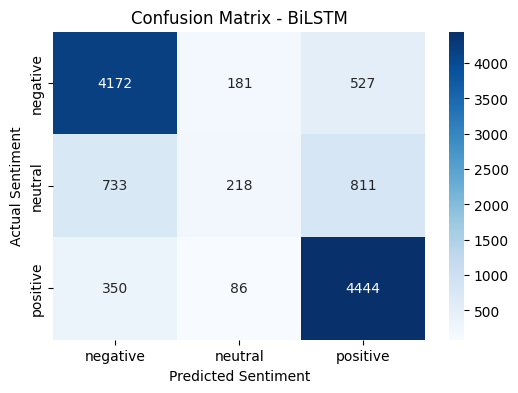

In [64]:
# BiLSTM Confusion Matrix

cm_bilstm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_bilstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [65]:
#Show Results
print("BiLSTM Results")
print("Accuracy :", bilstm_accuracy)
print("Precision:", bilstm_precision)
print("Recall   :", bilstm_recall)
print("F1 Score :", bilstm_f1)

BiLSTM Results
Accuracy : 0.7667071688942891
Precision: 0.7305159818890871
Recall   : 0.7667071688942891
F1 Score : 0.731432564661491


In [66]:
#Add to Comparison Table

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135


In [67]:
new_row = pd.DataFrame({
    'Model': ['BiLSTM'],
    'Accuracy': [bilstm_accuracy],
    'Precision': [bilstm_precision],
    'Recall': [bilstm_recall],
    'F1-Score': [bilstm_f1]
})

results_df = pd.concat(
    [results_df, new_row],
    ignore_index=True
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135
4,BiLSTM,0.766707,0.730516,0.766707,0.731433


## 11.2 GRU Model

In [68]:
class GRUClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        output_dim=3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, input_ids):

        embedded = self.embedding(
            input_ids
        )

        _, hidden = self.gru(
            embedded
        )

        hidden = torch.cat(
            (
                hidden[-2],
                hidden[-1]
            ),
            dim=1
        )

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output

In [69]:
model_gru = GRUClassifier(
    vocab_size=tokenizer.vocab_size,
    output_dim=3
)

model_gru = model_gru.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_gru.parameters(),
    lr=0.001
)

print("GRU initialized!")

GRU initialized!


In [70]:
# ==========================
# Train GRU
# ==========================

EPOCHS = 3

for epoch in range(EPOCHS):

    model_gru.train()

    running_loss = 0

    for batch in train_loader:

        input_ids = batch['input_ids'].to(device)

        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model_gru(input_ids)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Loss: {running_loss:.4f}"
    )

print("GRU Training Completed!")

Epoch 1/3, Loss: 891.3898
Epoch 2/3, Loss: 859.5603
Epoch 3/3, Loss: 854.5741
GRU Training Completed!


In [71]:
# ==========================
# Evaluate GRU
# ==========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model_gru.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)

        labels = batch['labels'].to(device)

        outputs = model_gru(input_ids)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

gru_accuracy = accuracy_score(
    true_labels,
    predictions
)

gru_precision = precision_score(
    true_labels,
    predictions,
    average='weighted'
)

gru_recall = recall_score(
    true_labels,
    predictions,
    average='weighted'
)

gru_f1 = f1_score(
    true_labels,
    predictions,
    average='weighted'
)

print("Classification Report - GRU")

print(
    classification_report(
        true_labels,
        predictions
    )
)

Classification Report - GRU
              precision    recall  f1-score   support

           0       0.79      0.87      0.82      4880
           1       0.42      0.22      0.29      1762
           2       0.81      0.87      0.84      4880

    accuracy                           0.77     11522
   macro avg       0.67      0.65      0.65     11522
weighted avg       0.74      0.77      0.75     11522



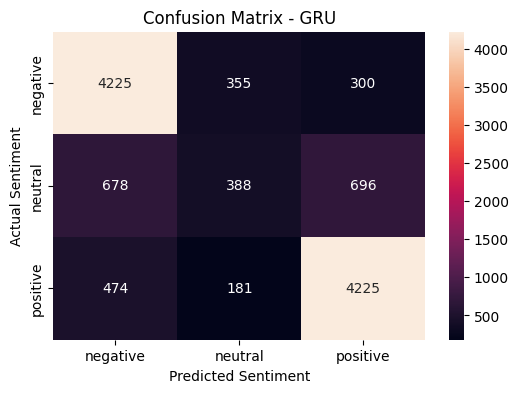

In [72]:
cm_gru = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [73]:
print("GRU Results")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)

GRU Results
Accuracy : 0.7670543308453394
Precision: 0.7397517397213181
Recall   : 0.7670543308453394
F1 Score : 0.7474134953869258


In [74]:
new_row = pd.DataFrame({
    'Model': ['GRU'],
    'Accuracy': [gru_accuracy],
    'Precision': [gru_precision],
    'Recall': [gru_recall],
    'F1-Score': [gru_f1]
})

results_df = pd.concat(
    [results_df, new_row],
    ignore_index=True
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135
4,BiLSTM,0.766707,0.730516,0.766707,0.731433
5,GRU,0.767054,0.739752,0.767054,0.747413


# 12. Transformer-Based Models

## 12.1 DistilBERT

In [75]:
!pip install transformers datasets accelerate

  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
Using cached datasets-5.0.0-py3-none-any.whl (555 kB)


In [76]:
import transformers
print(transformers.__version__)

5.9.0


In [77]:
!pip install torch torchvision torchaudio

In [78]:
!pip uninstall datasets -y
!pip install transformers accelerate torch

Found existing installation: datasets 5.0.0
Uninstalling datasets-5.0.0:
  Successfully uninstalled datasets-5.0.0


In [79]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("Transformers imported successfully!")

Transformers imported successfully!


In [80]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# Use original review text or cleaned review text
X = df_balanced['Review'].astype(str)
y = df_balanced['Sentiment']

# Convert labels into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Sentiment labels:")
for label, number in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "=", number)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Sentiment labels:
negative = 0
neutral = 1
positive = 2
Training size: 46085
Testing size: 11522


In [82]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization completed!")

Tokenization completed!


In [83]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

print("PyTorch datasets created!")

PyTorch datasets created!


In [84]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_encoder.classes_)
)

print("DistilBERT model loaded!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded!


In [85]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted'
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [93]:
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./distilbert_logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [94]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [95]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.598807,0.602699,0.778771,0.766094,0.778771,0.770567
2,0.501270,0.595430,0.779292,0.766393,0.779292,0.770947


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11522, training_loss=0.590443275430471, metrics={'train_runtime': 6149.9891, 'train_samples_per_second': 14.987, 'train_steps_per_second': 1.873, 'total_flos': 739261472814540.0, 'train_loss': 0.590443275430471, 'epoch': 2.0})

In [96]:
eval_results = trainer.evaluate()

print("DistilBERT Evaluation Results:")
print(eval_results)

c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.501270,0.595430,2,0.779292,0.766393,0.779292,0.770947


DistilBERT Evaluation Results:
{'eval_loss': 0.5954298973083496, 'eval_accuracy': 0.7792917896198577, 'eval_precision': 0.7663930838024855, 'eval_recall': 0.7792917896198577, 'eval_f1': 0.770946948671854}


c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report - DistilBERT
              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      4880
     neutral       0.43      0.33      0.37      1762
    positive       0.81      0.89      0.85      4880

    accuracy                           0.78     11522
   macro avg       0.69      0.68      0.69     11522
weighted avg       0.77      0.78      0.77     11522



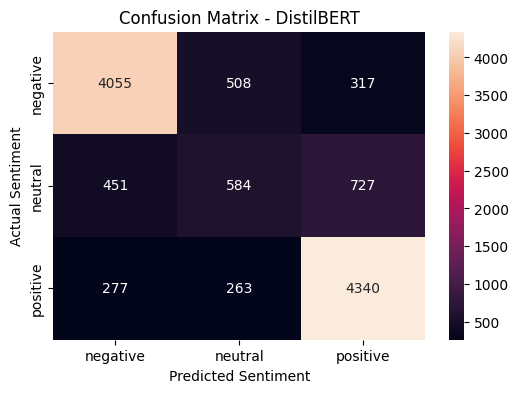

In [97]:
predictions = trainer.predict(test_dataset)

y_pred_distilbert = np.argmax(predictions.predictions, axis=1)

print("Classification Report - DistilBERT")
print(classification_report(
    y_test,
    y_pred_distilbert,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_pred_distilbert)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [98]:
distilbert_result = {
    "Model": "DistilBERT",
    "Accuracy": eval_results['eval_accuracy'],
    "Precision": eval_results['eval_precision'],
    "Recall": eval_results['eval_recall'],
    "F1-Score": eval_results['eval_f1']
}

results_df = pd.concat(
    [results_df, pd.DataFrame([distilbert_result])],
    ignore_index=True
)

print("Updated Model Comparison:")
display(results_df)

Updated Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135
4,BiLSTM,0.766707,0.730516,0.766707,0.731433
5,GRU,0.767054,0.739752,0.767054,0.747413
6,DistilBERT,0.779292,0.766393,0.779292,0.770947


## 12.2 RoBERTa

In [99]:
from transformers import RobertaTokenizerFast

tokenizer_roberta = RobertaTokenizerFast.from_pretrained(
    "roberta-base"
)

In [100]:
train_encodings_roberta = tokenizer_roberta(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings_roberta = tokenizer_roberta(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=64
)

print("RoBERTa Tokenization completed!")

RoBERTa Tokenization completed!


In [101]:
train_dataset_roberta = SentimentDataset(
    train_encodings_roberta,
    y_train
)

test_dataset_roberta = SentimentDataset(
    test_encodings_roberta,
    y_test
)

In [102]:
from transformers import RobertaForSequenceClassification

model_roberta = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(label_encoder.classes_)
)

print("RoBERTa model loaded!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded!


In [103]:
training_args_roberta = TrainingArguments(
    output_dir='./roberta_results',

    num_train_epochs=1,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    logging_dir='./roberta_logs',

    eval_strategy="epoch",
    save_strategy="epoch"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [104]:
trainer_roberta = Trainer(
    model=model_roberta,
    args=training_args_roberta,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer created!")

RoBERTa Trainer created!


In [105]:
trainer_roberta.train()

c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.592846,0.590320,0.778337,0.765505,0.778337,0.770032


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2881, training_loss=0.6255977409492554, metrics={'train_runtime': 18668.6725, 'train_samples_per_second': 2.469, 'train_steps_per_second': 0.154, 'total_flos': 1515697731999360.0, 'train_loss': 0.6255977409492554, 'epoch': 1.0})

In [106]:
eval_results_roberta = trainer_roberta.evaluate()

print(eval_results_roberta)

c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.592846,0.590320,1,0.778337,0.765505,0.778337,0.770032


{'eval_loss': 0.5903196334838867, 'eval_accuracy': 0.7783370942544697, 'eval_precision': 0.765504724510137, 'eval_recall': 0.7783370942544697, 'eval_f1': 0.7700318341151476}


In [107]:
predictions_roberta = trainer_roberta.predict(
    test_dataset_roberta
)

y_pred_roberta = np.argmax(
    predictions_roberta.predictions,
    axis=1
)

c:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [108]:
print(
    classification_report(
        y_test,
        y_pred_roberta,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      4880
     neutral       0.43      0.33      0.37      1762
    positive       0.80      0.89      0.84      4880

    accuracy                           0.78     11522
   macro avg       0.69      0.68      0.69     11522
weighted avg       0.77      0.78      0.77     11522



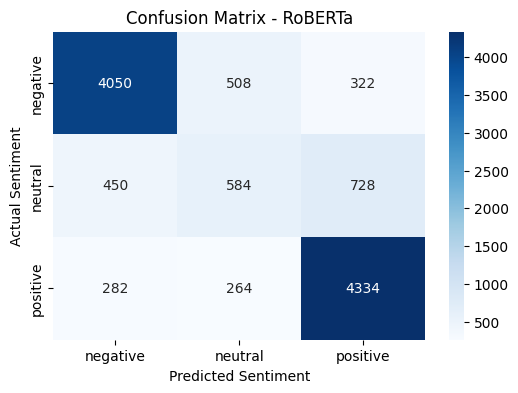

In [109]:
# ==========================
# RoBERTa Confusion Matrix
# ==========================

cm_roberta = confusion_matrix(
    y_test,
    y_pred_roberta
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_roberta,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - RoBERTa")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [110]:
roberta_result = {
    "Model": "RoBERTa",
    "Accuracy": eval_results_roberta['eval_accuracy'],
    "Precision": eval_results_roberta['eval_precision'],
    "Recall": eval_results_roberta['eval_recall'],
    "F1-Score": eval_results_roberta['eval_f1']
}

results_df = pd.concat(
    [results_df, pd.DataFrame([roberta_result])],
    ignore_index=True
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135
4,BiLSTM,0.766707,0.730516,0.766707,0.731433
5,GRU,0.767054,0.739752,0.767054,0.747413
6,DistilBERT,0.779292,0.766393,0.779292,0.770947
7,RoBERTa,0.778337,0.765505,0.778337,0.770032


# 13. Final Model Evaluation and Comparison

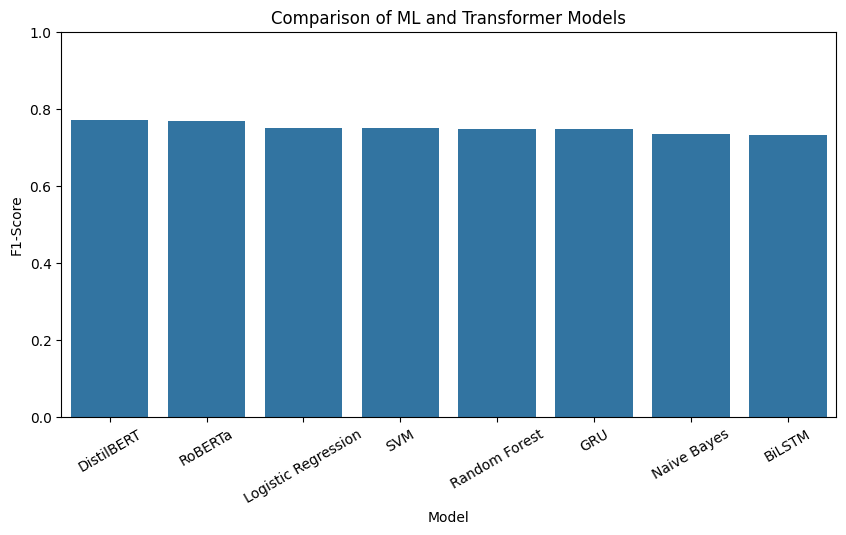

In [111]:
results_df_sorted = results_df.sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df_sorted,
    x="Model",
    y="F1-Score"
)

plt.title("Comparison of ML and Transformer Models")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

In [112]:
results_df_sorted.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [113]:
best_model = results_df_sorted.iloc[0]

print("Best Model:")
print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1-Score:", best_model["F1-Score"])

Best Model:
Model: DistilBERT
Accuracy: 0.7792917896198577
Precision: 0.7663930838024855
Recall: 0.7792917896198577
F1-Score: 0.770946948671854


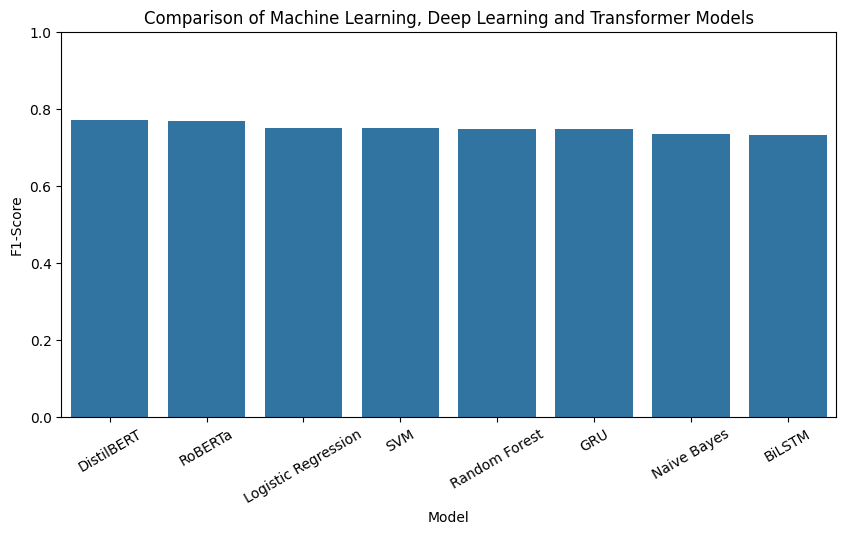

Chart saved as model_comparison_chart.png


In [114]:
results_df_sorted = results_df.sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df_sorted,
    x="Model",
    y="F1-Score"
)

plt.title("Comparison of Machine Learning, Deep Learning and Transformer Models")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.savefig("model_comparison_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved as model_comparison_chart.png")

In [115]:
comparison_table = results_df_sorted[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]

print("Final Comparison Table")

display(comparison_table)

Final Comparison Table


,Model,Accuracy,Precision,Recall,F1-Score
6,DistilBERT,0.779292,0.766393,0.779292,0.770947
7,RoBERTa,0.778337,0.765505,0.778337,0.770032
1,Logistic Regression,0.769051,0.743098,0.769051,0.749966
2,SVM,0.768790,0.742880,0.768790,0.749830
3,Random Forest,0.768183,0.742208,0.768183,0.749135
5,GRU,0.767054,0.739752,0.767054,0.747413
0,Naive Bayes,0.760198,0.734311,0.760198,0.734943
4,BiLSTM,0.766707,0.730516,0.766707,0.731433


# 14. Sample Prediction Testing

In [116]:
sample_reviews = [
    "The product quality is excellent and delivery was fast",
    "Very bad product, waste of money",
    "The item is okay but packaging could be better"
]

sample_encodings = tokenizer(
    sample_reviews,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

model.eval()

with torch.no_grad():
    outputs = model(**sample_encodings)
    predictions = torch.argmax(outputs.logits, dim=1)

predicted_labels = label_encoder.inverse_transform(predictions.numpy())

for review, sentiment in zip(sample_reviews, predicted_labels):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: The product quality is excellent and delivery was fast
Predicted Sentiment: positive

Review: Very bad product, waste of money
Predicted Sentiment: negative

Review: The item is okay but packaging could be better
Predicted Sentiment: negative

